In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize


In [ ]:
import bz2
import pandas as pd

data = []

with bz2.open('/content/test.ft.txt.bz2', 'rt', encoding='utf-8') as file:
    for line in file:
        parts = line.split(' ', 1)

        label = parts[0]
        text = parts[1] if len(parts) > 1 else ""

        data.append([label, text])

df = pd.DataFrame(data, columns=['label', 'text'])

df.head()

,label,text
0,__label__2,Great CD: My lovely Pat has one of the GREAT v...
1,__label__2,One of the best game music soundtracks - for a...
2,__label__1,Batteries died within a year ...: I bought thi...
3,__label__2,"works fine, but Maha Energy is better: Check o..."
4,__label__2,Great for the non-audiophile: Reviewed quite a...


In [ ]:
df.shape



(400000, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   400000 non-null  object
 1   text    400000 non-null  object
dtypes: object(2)
memory usage: 6.1+ MB


In [ ]:
df.isnull().sum()

,0
label,0
text,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['text'].isnull().sum()

np.int64(0)

In [ ]:
df = df.dropna(subset=['text']).copy()

In [ ]:
df['char_count'] = df['text'].apply(len)

In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

In [ ]:
df['sentence_count'] = df['text'].apply(lambda x: len(re.findall(r'[.!?]+', str(x))))

In [ ]:
df['avg_word_length'] = df['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0)


In [ ]:
df['uppercase_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

In [ ]:
df['digit_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isdigit()))

In [ ]:
df['punctuation_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c in string.punctuation))

In [ ]:
df['space_count'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isspace()))

In [ ]:
df[['char_count', 'word_count', 'sentence_count', 'avg_word_length', 'uppercase_count', 'digit_count', 'punctuation_count', 'space_count']].describe()

,char_count,word_count,sentence_count,avg_word_length,uppercase_count,digit_count,punctuation_count,space_count
count,400000.000000,400000.000000,400000.00000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000
mean,432.429630,78.424145,5.65156,4.524203,16.567145,1.539515,14.451105,78.424148
std,237.435383,42.798609,3.16769,0.456878,29.075983,3.472593,9.691222,42.798613
min,100.000000,6.000000,0.00000,1.051724,0.000000,0.000000,1.000000,6.000000
25%,232.000000,42.000000,3.00000,4.218750,6.000000,0.000000,7.000000,42.000000
50%,384.000000,70.000000,5.00000,4.481013,11.000000,0.000000,12.000000,70.000000
75%,596.000000,108.000000,7.00000,4.777778,19.000000,2.000000,19.000000,108.000000
max,1016.000000,230.000000,59.00000,23.461538,806.000000,572.000000,625.000000,230.000000


In [ ]:
df['sentence_count'].describe()

,sentence_count
count,400000.00000
mean,5.65156
std,3.16769
min,0.00000
25%,3.00000
50%,5.00000
75%,7.00000
max,59.00000


In [ ]:
display(df['avg_word_length'].head())

,avg_word_length
0,4.037736
1,4.520270
2,4.600000
3,5.216216
4,4.985507


In [ ]:
display(df['space_count'].head())

,space_count
0,106
1,148
2,60
3,37
4,69


In [ ]:
display(df['uppercase_count'].head())

,uppercase_count
0,62
1,19
2,8
3,13
4,16


In [ ]:
df['is_short_review'] = df['word_count'] < 3

In [ ]:
display(df['is_short_review'].head(10))

,is_short_review
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
df['has_url'] = df['text'].apply(lambda x: bool(re.search(r'http\S+|www\S+', str(x))))

In [ ]:
display(df['has_url'].head(20))

,has_url
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
df[df['has_url'] == True][['text', 'has_url']].head()

,text,has_url
254,"This book is messed up: In this book, not only...",True
1545,"What a cutie!: When I think of Clay, the first...",True
2148,"a total rip if you own ""Music has the right to...",True
2462,Ewwwww...: What the hell? Weird and beyond dis...,True
3341,Inspired movie!: I saw this movie on TBN chann...,True


In [ ]:
df['has_html'] = df['text'].apply(lambda x: bool(re.search(r'<.*?>', str(x))))

In [ ]:
df['has_repeated_punct'] = df['text'].apply(lambda x: bool(re.search(r'([!?.,])\1{2,}', str(x))))

In [ ]:
df['has_repeated_chars'] = df['text'].apply(lambda x: bool(re.search(r'(.)\1{3,}', str(x))))

In [ ]:
df['uppercase_ratio'] = df['uppercase_count'] / df['char_count']
df['is_shouting'] = df['uppercase_ratio'] > 0.3

In [ ]:
df['has_special_chars'] = df['text'].apply(lambda x: bool(re.search(r'[^a-zA-Z0-9\s.,!?\'"-]', str(x))))

In [ ]:
profile_summary = {
    "total_reviews": len(df),
    "duplicate_rows": df.duplicated().sum(),
    "avg_char_count": df['char_count'].mean(),
    "avg_word_count": df['word_count'].mean(),
    "reviews_with_url": df['has_url'].sum(),
    "reviews_with_html": df['has_html'].sum(),
    "short_reviews": df['is_short_review'].sum(),
    "repeated_punctuation_reviews": df['has_repeated_punct'].sum(),
    "repeated_character_reviews": df['has_repeated_chars'].sum(),
    "shouting_reviews": df['is_shouting'].sum(),
    "special_char_reviews": df['has_special_chars'].sum()
}

profile_summary

{'total_reviews': 400000,
 'duplicate_rows': np.int64(0),
 'avg_char_count': np.float64(432.42963),
 'avg_word_count': np.float64(78.424145),
 'reviews_with_url': np.int64(750),
 'reviews_with_html': np.int64(216),
 'short_reviews': np.int64(0),
 'repeated_punctuation_reviews': np.int64(81411),
 'repeated_character_reviews': np.int64(30218),
 'shouting_reviews': np.int64(3938),
 'special_char_reviews': np.int64(400000)}

In [ ]:
pd.DataFrame(profile_summary.items(), columns=['Metric', 'Value'])




,Metric,Value
0,total_reviews,400000.000000
1,duplicate_rows,0.000000
2,avg_char_count,432.429630
3,avg_word_count,78.424145
4,reviews_with_url,750.000000
5,reviews_with_html,216.000000
6,short_reviews,0.000000
7,repeated_punctuation_reviews,81411.000000
8,repeated_character_reviews,30218.000000
9,shouting_reviews,3938.000000


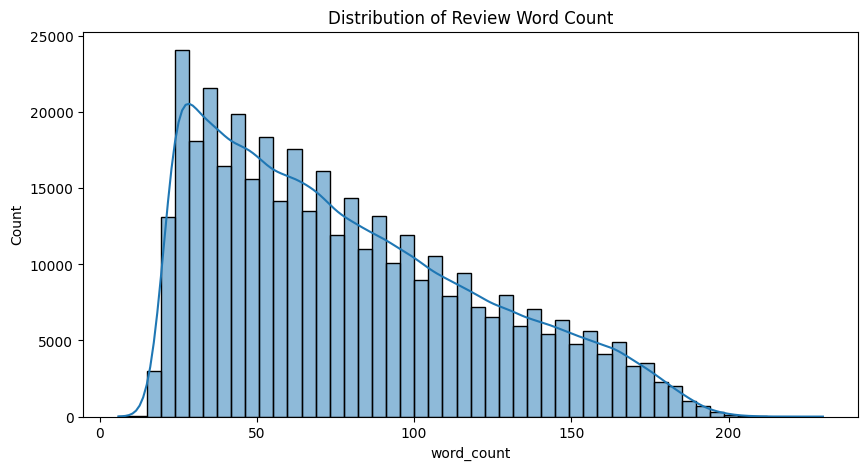

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Distribution of Review Word Count")
plt.show()

In [ ]:
def clean_review(text):
    text = str(text)

    # remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # normalize repeated punctuation
    text = re.sub(r'([!?.,])\1{1,}', r'\1', text)

    # normalize repeated characters (example: goooood -> good)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove extra special characters except basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'"-]', ' ', text)

    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df['clean_text'] = df['text'].apply(clean_review)

In [ ]:
comparison = df[['text', 'clean_text']].sample(10, random_state=42)
comparison

,text,clean_text
23218,This is a great book: I must preface this by s...,This is a great book I must preface this by sa...
20731,"Huge Disappointment.: As a big time, long term...","Huge Disappointment. As a big time, long term ..."
39555,Wayne is tight but cant hang with Turk.: This ...,Wayne is tight but cant hang with Turk. This a...
147506,Excellent: I read this book when I was in elem...,Excellent I read this book when I was in eleme...
314215,Not about Anusara: Although this book is toute...,Not about Anusara Although this book is touted...
190913,Worst DVD Ever purchased: This was the very wo...,Worst DVD Ever purchased This was the very wor...
296715,"Not the strongest fan, but gets the job done.:...","Not the strongest fan, but gets the job done. ..."
141482,Bottom of the casebook barrel: At the beginnin...,Bottom of the casebook barrel At the beginning...
49119,"Hilarious!: This movie is very sweet, I love i...","Hilarious! This movie is very sweet, I love it..."
208005,"The swinging, sadly, occurs only in the title....","The swinging, sadly, occurs only in the title...."


NLP Architecture Pipeline

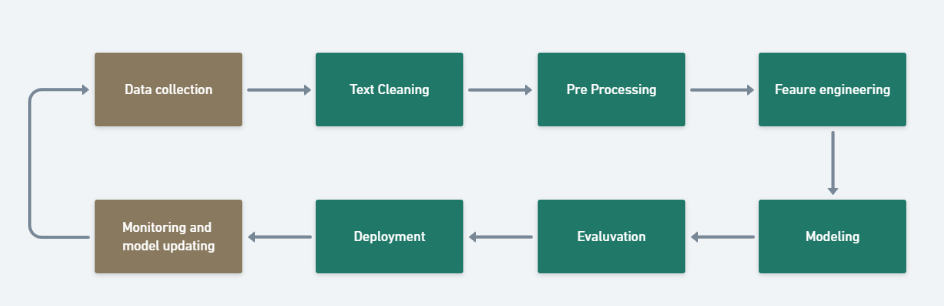